# Book Genre Multi Label Text Classification (text-based)
### **Course and Year:** TU862/2, ML/AI stream
### **Module:** Project
### **Group Members:** 
##### **Student 1:** Kornel Zaleski X00222004 
##### **Student 2:** Lukasz Kiraga X00227628 
##### **Student 3:** Blessing Mayindu X00224444
##### Goal: The goal for this project is to predict the book genre based on its summary.

## 1. Importing Necessary Libraries

In [3]:
 #!pip install numpy
 !pip install transformers accelerate -q
 #!pip install matplotlib
 #!pip install scikit-learn
 #!pip install scikit-multilearn
 #!pip install pandas
 #!pip install torch torchvision torchaudio
 #!pip install tensorflow
 #!pip install transformers
 #!pip install pandas 
 #!pip install tabulate
 #!pip install "accelerate>=1.1.0"
 #!pip install ipywidgets -q
#!pip install transformers accelerate -q

In [4]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from skmultilearn.model_selection import iterative_train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report, hamming_loss
import joblib
from sklearn.metrics import classification_report ,f1_score
import pandas as pd
import tensorflow as tf
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# https://pytorch.org/get-started/locally/
gpu_available = torch.cuda.is_available()
if gpu_available:
    print("CUDA Version:", torch.version.cuda)
    print("GPU Name:", torch.cuda.get_device_name(0))

import transformers
from transformers import BertTokenizer, BertModel, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.feature_extraction.text import TfidfVectorizer
import glob
import os
import sys
import accelerate
print(accelerate.__version__)  # Should show 1.1.0 or higher
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import DistilBertForSequenceClassification

from transformers import DistilBertTokenizer
from transformers import DistilBertForSequenceClassification
import os

# This will print all files in your input folder
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


2026-05-01 20:25:22.136257: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777667122.333544      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777667122.393857      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777667122.880762      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777667122.880797      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777667122.880799      57 computation_placer.cc:177] computation placer alr

CUDA Version: 12.8
GPU Name: Tesla T4
1.12.0
/kaggle/input/datasets/wasedrftgyhujiko/data-book/BooksDatasetClean.csv
/kaggle/input/datasets/wasedrftgyhujiko/data-book/GoodreadsDatasetClean.csv
/kaggle/input/datasets/wasedrftgyhujiko/data-book/GoogleBooksDatasetClean.csv
/kaggle/input/datasets/wasedrftgyhujiko/data-book/BooksDataset.csv
/kaggle/input/datasets/wasedrftgyhujiko/data-book/goodreads_data.csv
/kaggle/input/datasets/wasedrftgyhujiko/data-book/google_books_dataset.csv
/kaggle/input/datasets/wasedrftgyhujiko/data-book/MergedBooksDataset.csv


## 2.  Data Exploration

### Analysing data through the three datasets


-----------Dataset Shape & Columns-----------

Shape:  (103082, 5)
Columns:  ['Title', 'Author', 'Description', 'Category', 'Publisher']

-----------Description of dataset columns-----------

                 Title  Author  \
count           103082  102990   
unique           97813   63579   
top     The Nutcracker      By   
freq                12    1043   

                                              Description  \
count                                               70213   
unique                                              68831   
top     For Ingest Only - Data needs to be cleaned up ...   
freq                                                   30   

                    Category         Publisher  
count                  76911            103074  
unique                  3106             13029  
top     "Fiction", "General"  Simon & Schuster  
freq                    2549              1521   


-----------Dataset Overall Info-----------

<class 'pandas.core.frame.DataFrame'>


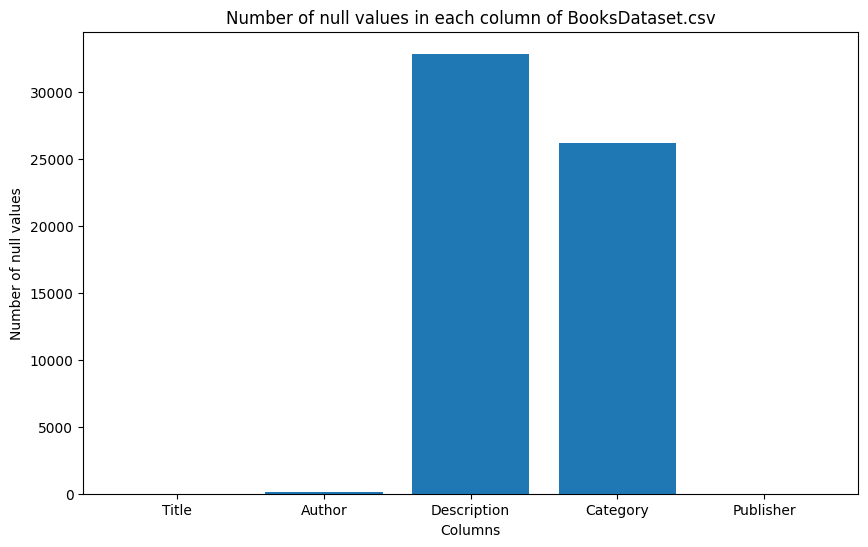

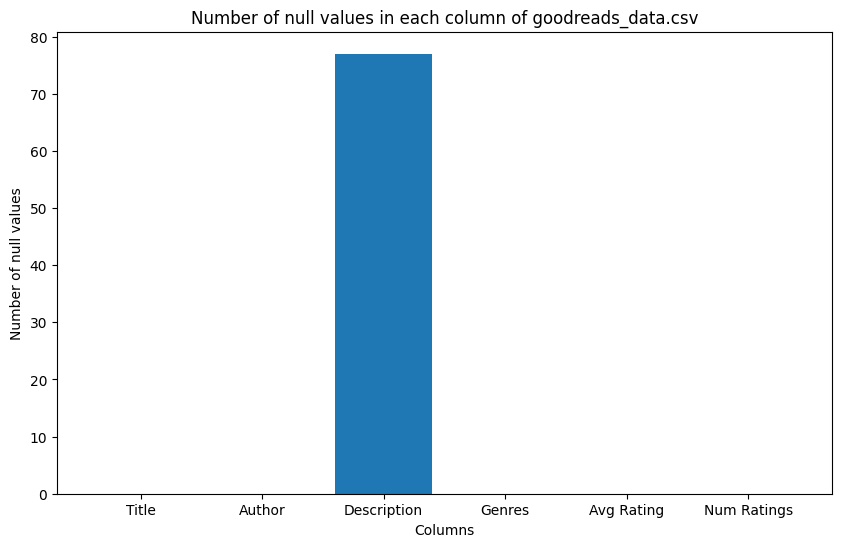

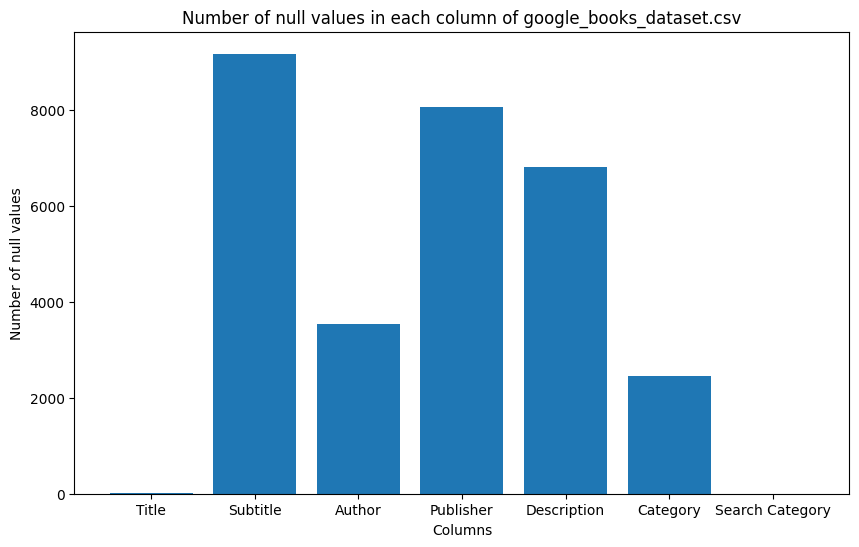

In [5]:
# BooksDataset.csv - df1
df1 = pd.read_csv('/kaggle/input/datasets/wasedrftgyhujiko/data-book/BooksDataset.csv')
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df1.shape)
print("Columns: ", df1.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df1.describe(), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df1.info(), "\n")
print("\n" + ("-"*30), "\n")

# goodreads_data.csv - df2
df2 = pd.read_csv('/kaggle/input/datasets/wasedrftgyhujiko/data-book/goodreads_data.csv')
print("goodreads_data.csv loaded successfully.")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df2.shape)
print("Columns: ", df2.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df2.describe(include='all'), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df2.info(), "\n")
print("\n" + ("-"*30), "\n")


# google_books_dataset.csv - df3
df3 = pd.read_csv('/kaggle/input/datasets/wasedrftgyhujiko/data-book/google_books_dataset.csv')
print("google_books_dataset.csv loaded successfully.")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df3.shape)
print("Columns: ", df3.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df3.describe(), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df3.info())
print("\n" + ("-"*30), "\n")

# Number of nulls in not cleaned datasets
print("\nNull values in each uncleaned dataset\n")
print("Number of null values in BooksDataset.csv")
nulls_df1og = df1.isnull().sum()
print(nulls_df1og)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in goodreads_data.csv")
nulls_df2og = df2.isnull().sum()
print(nulls_df2og)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in google_books_dataset.csv")
nulls_df3og = df3.isnull().sum()
print(nulls_df3og)
print("\n" + ("-"*30), "\n")


# Display the first 15 rows of each not cleaned dataset for checking that cleaning worked as intended (checking if nan values are removed)
print("BooksDataset.csv\n\n", df1.head(15).to_markdown(index=False), "\n")
print("goodreads_data.csv\n\n", df2.head(15).to_markdown(index=False), "\n")
print("google_books_dataset.csv\n\n", df3.head(15).to_markdown(index=False), "\n")

# Data visualization of null values in not cleaned datasets

# BooksDataset.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df1og.index, nulls_df1og.values)
plt.title("Number of null values in each column of BooksDataset.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

# goodreads_data.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df2og.index, nulls_df2og.values)
plt.title("Number of null values in each column of goodreads_data.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

# google_books_dataset.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df3og.index, nulls_df3og.values)
plt.title("Number of null values in each column of google_books_dataset.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

## 3. Data Cleaning
### Each dataset will be cleaned before merging


Null values in each cleaned dataset

Number of null values in BooksDatasetClean.csv
Title           0
Author         11
Description     0
Category        0
Publisher       0
dtype: int64

------------------------------ 


Number of null values in GoodreadsDatasetClean.csv
Title          0
Author         0
Description    0
Genres         0
Avg Rating     0
Num Ratings    0
dtype: int64

------------------------------ 


Number of null values in GoogleBooksDatasetClean.csv
Title                 0
Subtitle           3565
Author              299
Publisher          1135
Description           0
Category              0
Search Category       0
dtype: int64

------------------------------ 


Null values comparison (uncleaned vs cleaned)

BooksDataset.csv vs BooksDatasetClean.csv
              Uncleaned  Cleaned
Title                0        0
Author              92       11
Description      32869        0
Category         26171        0
Publisher            8        0 


----------------------

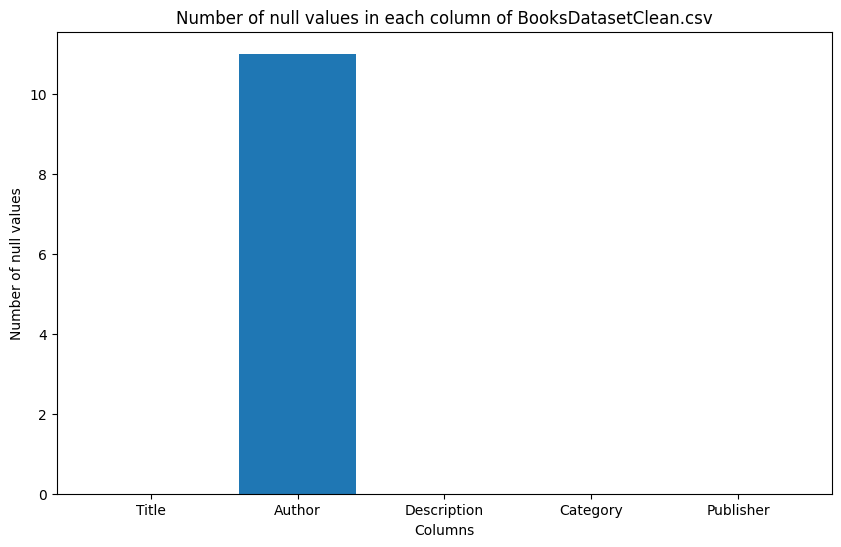

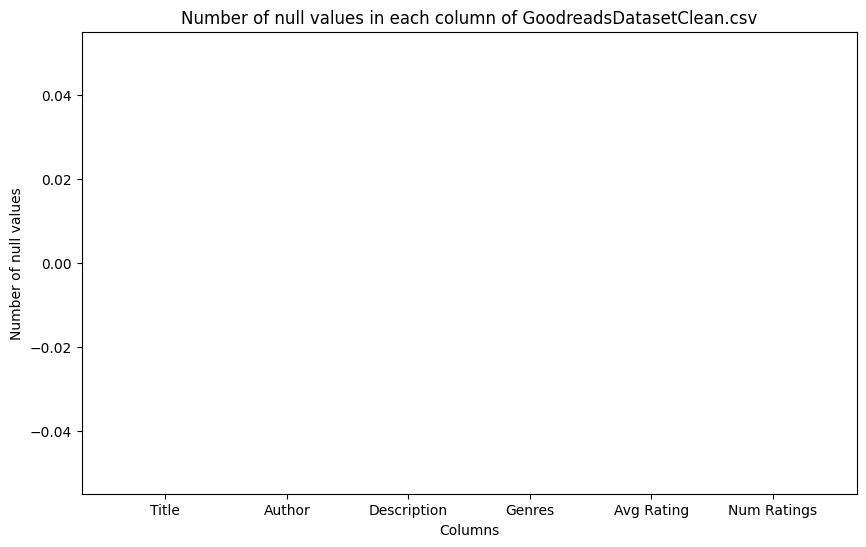

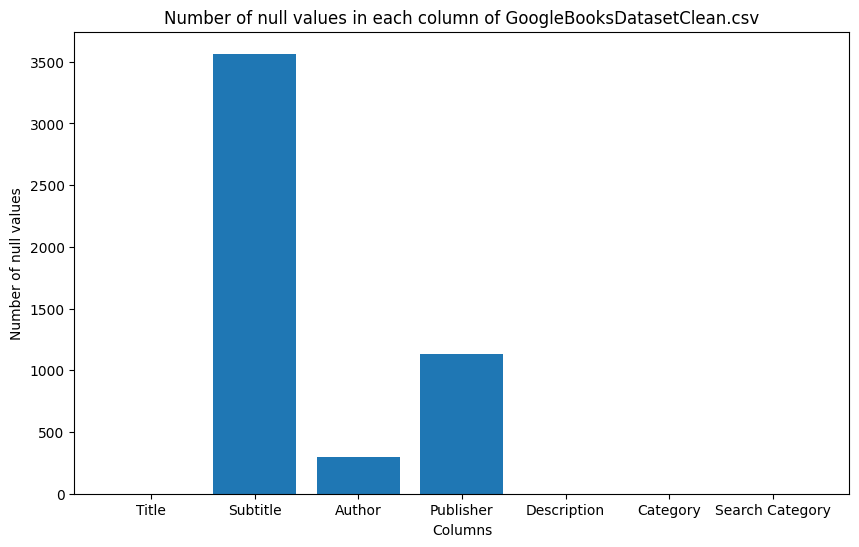

In [6]:
# Load and save the cleaned datasets

# BooksDataset.csv - df1
df1 = df1.dropna(subset=['Title', 'Description', 'Category'], how='any')
df1 = df1.drop_duplicates()
#df1.to_csv('BooksDatasetClean.csv', encoding="utf-8", index=False)

# goodreads_data.csv - df2
df2 = df2.dropna(subset=['Title', 'Description', 'Genres'], how='any')
df2 = df2.drop_duplicates()
#df2.to_csv('GoodreadsDatasetClean.csv', encoding="utf-8", index=False)

# google_books_dataset.csv - df3
df3 = df3.dropna(subset=['Title', 'Description', 'Category'], how='any')
df3 = df3.drop_duplicates()
#df3.to_csv('GoogleBooksDatasetClean.csv', encoding="utf-8", index=False)

# Number of nulls in cleaned datasets
print("\nNull values in each cleaned dataset\n")
print("Number of null values in BooksDatasetClean.csv")
nulls_df1 = df1.isnull().sum()
print(nulls_df1)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in GoodreadsDatasetClean.csv")
nulls_df2 = df2.isnull().sum()
print(nulls_df2)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in GoogleBooksDatasetClean.csv")
nulls_df3 = df3.isnull().sum()
print(nulls_df3)
print("\n" + ("-"*30), "\n")

# Nulls in each uncleaned and cleaned datasets comparison
print("\nNull values comparison (uncleaned vs cleaned)\n")
print("BooksDataset.csv vs BooksDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df1og, 'Cleaned': nulls_df1}), "\n")
print("\n" + ("-"*30), "\n")
print("goodreads_data.csv vs GoodreadsDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df2og, 'Cleaned': nulls_df2}), "\n")
print("\n" + ("-"*30), "\n")
print("google_books_dataset.csv vs GoogleBooksDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df3og, 'Cleaned': nulls_df3}), "\n")
print("\n" + ("-"*30), "\n")

# Display the first 15 rows of each cleaned dataset to ensure the cleaning process
print("BooksDatasetClean.csv\n\n", df1.head(15).to_markdown(index=False), "\n")
print("GoodreadsDatasetClean.csv\n\n", df2.head(15).to_markdown(index=False), "\n")
print("GoogleBooksDatasetClean.csv\n\n", df3.head(15).to_markdown(index=False), "\n")

# Data visualization of null values in not cleaned datasets

# BooksDatasetClean.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df1.index, nulls_df1.values)
plt.title("Number of null values in each column of BooksDatasetClean.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

# GoodreadsDatasetClean.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df2.index, nulls_df2.values)
plt.title("Number of null values in each column of GoodreadsDatasetClean.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

# GoogleBooksDatasetClean.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df3.index, nulls_df3.values)
plt.title("Number of null values in each column of GoogleBooksDatasetClean.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

## 4. Data merging


In [7]:

# Merging two csv files

common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)

final_df = pd.concat(
    [df1[common_columns], df2[common_columns], df3[common_columns]],
    ignore_index=True
)

print(final_df.head())
# Here I am showing that the columns have difference headers . To fix this I need to make them the same and then put them together.
print("DF1 columns:")
print(df1.columns.tolist())

print("\nDF2 columns:")
print(df2.columns.tolist())

print("\nDF3 columns:")
print(df3.columns.tolist())

# Making all the columns lowercase
for df in [df1, df2, df3]:
    df.columns = df.columns.str.lower().str.strip()

common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)
print(common_columns)

                                               Title  \
0                         Journey Through Heartsongs   
1                       In Search of Melancholy Baby   
2       The Dieter's Guide to Weight Loss During Sex   
3  Germs : Biological Weapons and America's Secre...   
4  The Good Book: Reading the Bible with Mind and...   

                                              Author  \
0                             Stepanek, Mattie J. T.   
1  Aksyonov, Vassily, Heim, Michael Henry, and Bo...   
2                                     Smith, Richard   
3  Miller, Judith, Engelberg, Stephen, and Broad,...   
4                                    Gomes, Peter J.   

                                         Description  
0  Collects poems written the eleven-year-old mus...  
1  The Russian author offers an affectionate chro...  
2  A humor classic, this tongue-in-cheek diet pla...  
3  Deadly germs sprayed in shopping malls, bomb-l...  
4  "The Bible and the social and moral consequenc..


Common columns: Index(['title', 'description'], dtype='object')
Number of null values in each column in the merged dataset:
title                  0
authors             7403
description            0
categories          7392
publisher          11039
avg rating         72618
num ratings        72618
subtitle           78695
author             75429
category           75130
search category    75130
dtype: int64

Final merged dataset:

-----------Dataset Shape & Columns-----------

Shape:  (82522, 11)
Columns:  ['title', 'authors', 'description', 'categories', 'publisher', 'avg rating', 'num ratings', 'subtitle', 'author', 'category', 'search category']

-----------Dataset First and Last 15 rows-----------

First 15 rows

 | title                                                                  | authors                                                                 | description                                                                                                              

Text(0, 0.5, 'Number of null values')

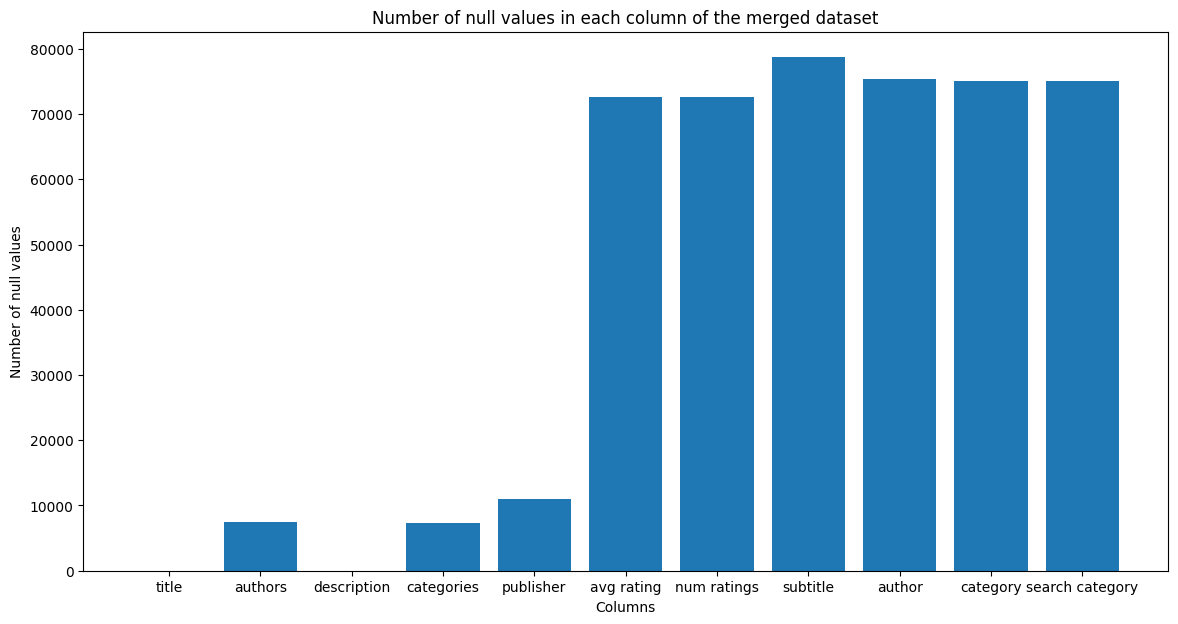

In [8]:
#Here I am matching header names to the df3 
#pandas.DataFrame.rename

dfs = []
for df_loop in [df1, df2, df3]:
    df_loop.columns = df_loop.columns.str.lower().str.strip()
    dfs.append(df_loop)

df1,df2,df3 = dfs

df2 = df2.rename(columns={
    "book": "title",
    "author": "authors",
    "genres": "categories"
})

df1 = df1.rename(columns={
    "category": "categories",
    "author": "authors"
})
#df1 = df1.rename(columns={"categories": "category"})
#df2 = df2.rename(columns={"categories": "category"})
#df3 = df3.rename(columns={"categories": "category"})

common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)

print("\nCommon columns:", common_columns)
# Merge
df = pd.concat([df1, df2, df3], ignore_index=True)
df.to_csv('MergedBooksDataset.csv', encoding="utf-8", index=False)

print("Number of null values in each column in the merged dataset:\n" + str(df.isnull().sum()))

print("\nFinal merged dataset:")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df.shape)
print("Columns: ", df.columns.tolist())
print("\n-----------Dataset First and Last 15 rows-----------\n")
print("First 15 rows\n\n", df.head(15).to_markdown(index=False), "\n")
print("Last 15 rows\n\n", df.tail(15).to_markdown(index=False), "\n")
print("\n-----------Description of dataset columns-----------\n")
print(df.describe(), "\n")
print("\n" + ("-"*30), "\n")
print("\nNumber of categories: ")
print(df["category"].value_counts().head(20))
print("\n-----------Dataset Overall Info-----------\n")
print(df.info())
print("Number of genres:", df["category"].value_counts().sum())

# Data visualization of null values in the merged dataset
plt.figure(figsize=(14, 7))
plt.bar(df.isnull().sum().index, df.isnull().sum().values)
plt.title("Number of null values in each column of the merged dataset")
plt.xlabel("Columns")
plt.ylabel("Number of null values")

### Data Visualisation - Categories

##### Using a bar chart from matplotlib, it will show the top 10 categories that are most frequently occurring in the merged dataset

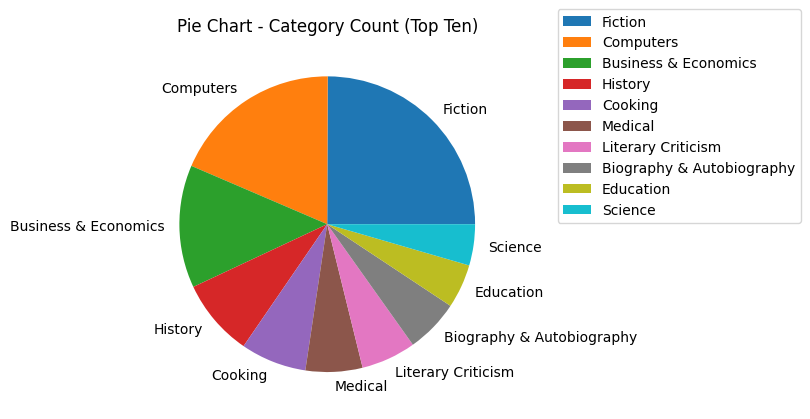

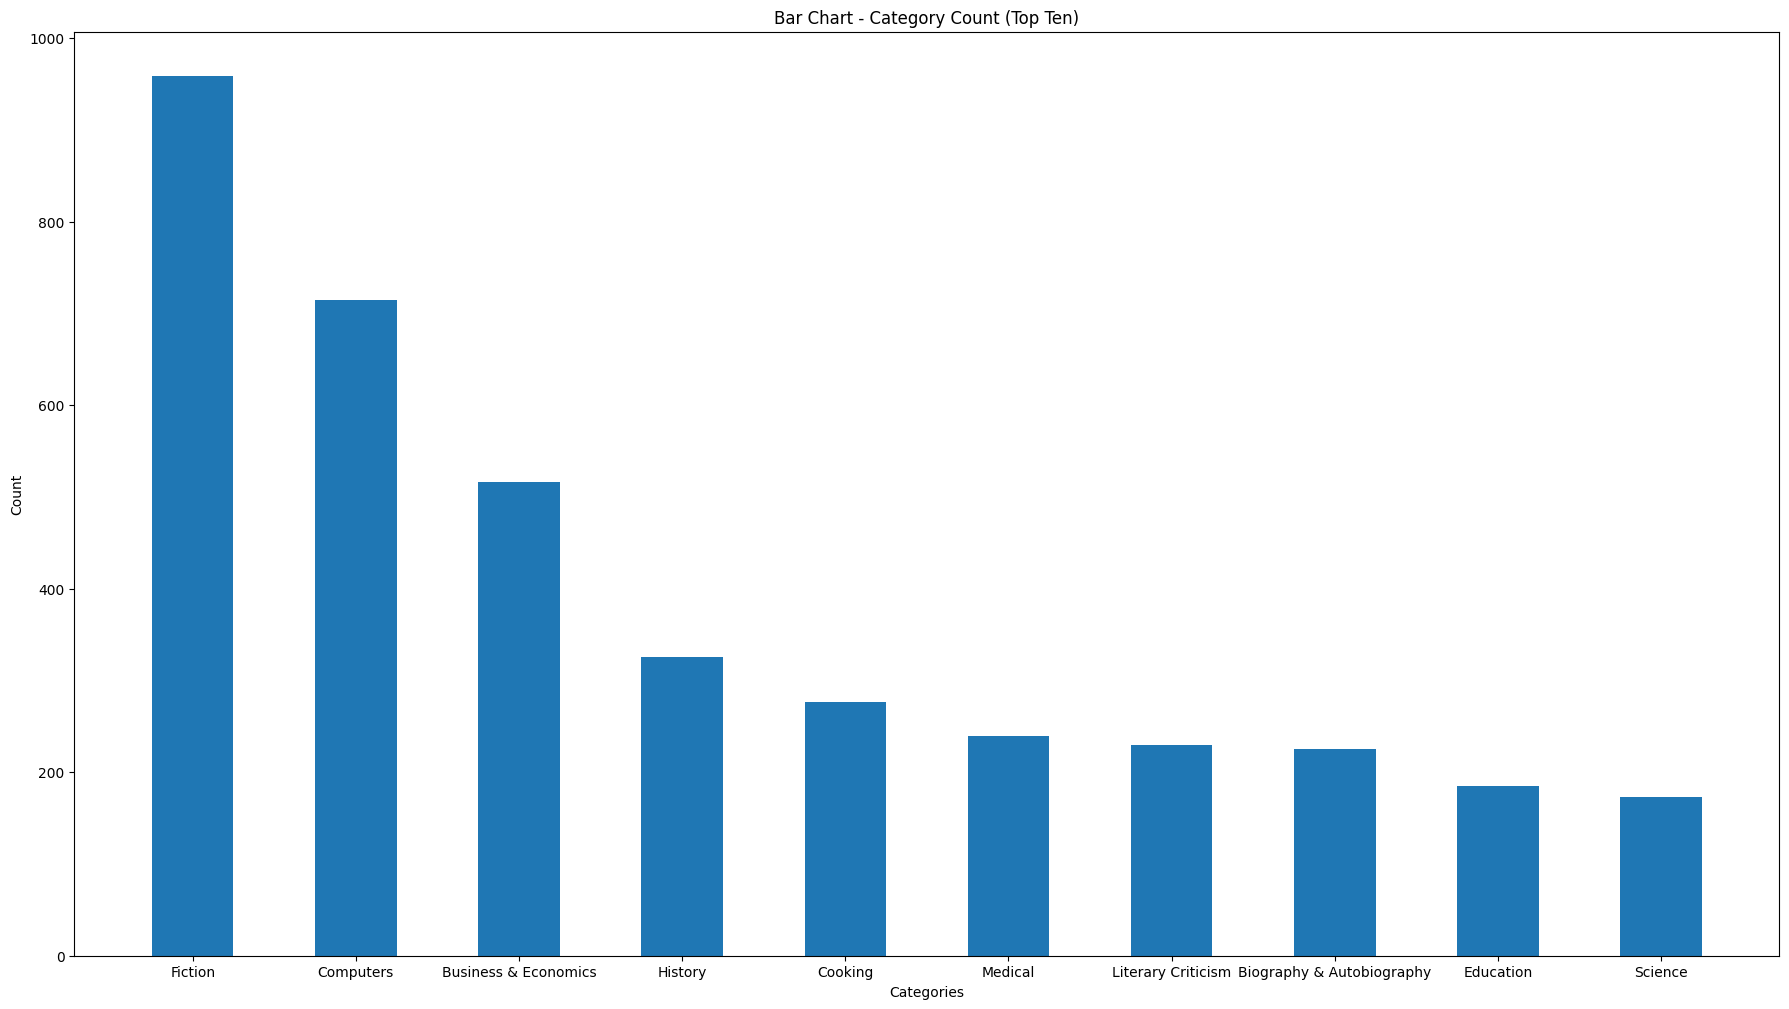

In [9]:
categories = df["category"].value_counts().head(10).index.tolist()
count = df["category"].value_counts().head(10).values.tolist()
new_categories = []

for category in categories:
    category = category.replace('"', '')
    new_categories.append(category)
    
categories = new_categories

plt.pie(count, labels=categories)
plt.title("Pie Chart - Category Count (Top Ten)")
plt.legend(categories, loc="upper right", bbox_to_anchor=(1.7, 1, 0.1, 0.1))
plt.show()

plt.figure(figsize=(22, 12))
plt.bar(categories, count, width=0.5)
plt.title("Bar Chart - Category Count (Top Ten)")
plt.xlabel("Categories")
plt.ylabel("Count")
plt.show()

## 5. Feature Selection

In [10]:
#tfidf = TfidfVectorizer()
mlb = MultiLabelBinarizer()
#result = tfidf.fit_transform(df)
#print('\nidf values:') 
#for ele1, ele2 in zip(tfidf.get_feature_names_out(),
#tfidf.idf_): print(ele1, ':', ele2) 
#print('\nWord indexes:') 
#print(tfidf.vocabulary_)
#print('\ntf-idf value:') 
#print(result) 
#print('\ntf-idf values in matrix form:') 
#print(result.toarray())
#the max feature will keep the 5000 most usefull words.
df = df.dropna(subset=['categories'], how='any')
tfidf = TfidfVectorizer(max_features=5000 ,stop_words='english')
# the stop word will remove useless word like 'a','is' etc -They are jsut filler words.
texts = (df['title'] + " " + df['description'])
X = texts
print(df['categories'].head(10))
categories_list = df['categories'].apply(lambda x: [category.strip().replace('"', '') for category in str(x).split(',')] if pd.notna(x) else []).tolist()
#categories_list = df['categories'].apply(lambda x: [x] if isinstance(x, str) else x)
y = mlb.fit_transform(categories_list)

print("Sample of the multi-label binarized output (first 5 rows):\n", y[:5])
print("feature matrix shape:", X.shape)
print("Number of genres:",len(mlb.classes_))
print("genre:", mlb.classes_)

0                                "Poetry", "General"
1             "Biography & Autobiography", "General"
2    "Health & Fitness", "Diet & Nutrition", "Diets"
3     "Technology & Engineering", "Military Science"
4        "Religion", "Biblical Biography", "General"
5    "Biography & Autobiography", "Personal Memoirs"
6                     "Political Science", "General"
7                          "Pets", "Cats", "General"
8                     "Political Science", "General"
9                               "Fiction", "General"
Name: categories, dtype: object
Sample of the multi-label binarized output (first 5 rows):
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
feature matrix shape: (75130,)
Number of genres: 2423
genre: ['12th Century' '15th Century' '16th Century' ... 'etc.' 'etc.)'
 'the Gospels & Acts']


## 6. Dataset Splits

#### We split the dataset into three sets:
 - **Training set**: fitting the models (70%)
 - **Validation set**: tuning and comparison (15%)
 - **Test set**: final unbiased evaluation (15%)

In [11]:
# Splitting the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Checking the shapes of the training, validation, and test sets
print("Training set shape: ", X_train.shape)
print("Validation set shape: ", X_val.shape)
print("Test set shape: ", X_test.shape)

# Checking the first 5 rows of training genres and the number of genres
print(mlb.inverse_transform(y_train[:5]))
print(len(mlb.classes_))

Training set shape:  (52591,)
Validation set shape:  (11269,)
Test set shape:  (11270,)
[('Fiction', 'General', 'Mystery & Detective'), ('Business & Economics', 'General', 'Investments & Securities'), ('American', 'Cooking', 'Regional & Ethnic', 'Southern States'), ('Juvenile Fiction', 'Media Tie-In'), ('Boating', 'Sports & Recreation')]
2423


## TF-IDF Vectorizer
#### We covert training, validation and test set texts into TF-IDF vectors so the ML models work 

In [12]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

## Machine Learning Models
### 1. Logistic Regression

In [13]:
# Initialise the Logistic Regression model with the maximum number of iterations as the parameter
# We use OneVsRestClassifier wrapper for multi-label classification
log_reg = OneVsRestClassifier(LogisticRegression(max_iter=100, solver='liblinear'))

# Fit the Logistic Regression model on the training data
log_reg.fit(X_train_tfidf, y_train)

# Make predictions on the validation and test sets
y_val_lr = log_reg.predict(X_val_tfidf)
y_test_lr = log_reg.predict(X_test_tfidf)

# Calculate accuracy classification scores
val_acc_lr = classification_report(y_val, y_val_lr, target_names=mlb.classes_)
test_acc_lr = classification_report(y_test, y_test_lr, target_names=mlb.classes_)

# Prints the validation and test accuracy of the Logistic Regression model
print("Validation Classification Report:\n", val_acc_lr, "\nTest Classification Report:\n", test_acc_lr)

/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 14 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 29 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 63 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 67 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 102 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 103 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 115 is present in all training ex

Validation Classification Report:
                                                            precision    recall  f1-score   support

                                             12th Century       0.00      0.00      0.00         0
                                             15th Century       0.00      0.00      0.00         1
                                             16th Century       0.00      0.00      0.00         1
                                             17th Century       0.00      0.00      0.00         1
                                             18th Century       0.00      0.00      0.00         1
                                             19th Century       0.00      0.00      0.00        35
                                             20th Century       0.00      0.00      0.00        43
                                             21st Century       0.00      0.00      0.00        11
                                                       A+       0.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

### 2. Naive Bayes

In [14]:
# Initialize the Naive Bayes model with the OneVsRestClassifier wrapper for multi-label classification
naive_bayes = OneVsRestClassifier(MultinomialNB())

# Fit the Naive Bayes model on the training data
naive_bayes.fit(X_train_tfidf, y_train)

# Make predictions on the validation and test sets
y_val_nb = naive_bayes.predict(X_val_tfidf)
y_test_nb = naive_bayes.predict(X_test_tfidf)

# Calculate accuracy classification scores
val_acc_nb = classification_report(y_val, y_val_nb, target_names=mlb.classes_)
test_acc_nb = classification_report(y_test, y_test_nb, target_names=mlb.classes_)

# Prints the validation and test accuracy of the Naive Bayes model
print("Validation Classification Report:\n", val_acc_nb, "\nTest Classification Report:\n", test_acc_nb)

/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 14 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 29 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 63 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 67 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 102 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 103 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 115 is present in all training ex

Validation Classification Report:
                                                            precision    recall  f1-score   support

                                             12th Century       0.00      0.00      0.00         0
                                             15th Century       0.00      0.00      0.00         1
                                             16th Century       0.00      0.00      0.00         1
                                             17th Century       0.00      0.00      0.00         1
                                             18th Century       0.00      0.00      0.00         1
                                             19th Century       0.00      0.00      0.00        35
                                             20th Century       0.00      0.00      0.00        43
                                             21st Century       0.00      0.00      0.00        11
                                                       A+       0.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

## Deep Learning Model

### 3. DistilBERT ( Distil Bidirectional Encoder Representations from Transformers)
##### We now do the BERT tokenizer so we firstly take the tokenizer from huggingface, then we initialise the tokenizer for the two sets with the function and then tokenize them.

In [15]:
# BERT Tokenizer
# Initialising the tokenizer from the hugging face transformers library for the BERT model.
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Function to tokenize the data using the tokenizer
def tokenize_data(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors='pt')

# Tokenizing the training, validation, and test data using the tokenize_data function
X_train_tokenize = tokenize_data(X_train)
X_valid_tokenize = tokenize_data(X_val)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### DistilBERT - Model Preparation and Fitting

In [16]:
# X_train_tokens = tokenizer.convert_ids_to_tokens(X_train_tokenize['input_ids'][0])
# print(X_train_tokens)
# X_valid_tokens = tokenizer.convert_ids_to_tokens(X_valid_tokenize['input_ids'][0])
# print(X_valid_tokens)

# Converting tokenized data to lists
train_encodings = {key: val.tolist() for key, val in X_train_tokenize.items()}
valid_encodings = {key: val.tolist() for key, val in X_valid_tokenize.items()}

# Custom dataset class for multi-label classification to prepare BERT
class MultiLabelBookGenreDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item
    
# Creating datasets for training and validation using the class above with the encodings and label splits
train_dataset = MultiLabelBookGenreDataset(train_encodings, y_train)
valid_dataset = MultiLabelBookGenreDataset(valid_encodings, y_val)

# Initialise BERT model for sequence classification
#model = BertForSequenceClassification.from_pretrained(
   # 'bert-base-uncased',
 #   num_labels=len(mlb.classes_),
 #   problem_type='multi_label_classification'
#)

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(mlb.classes_),
    problem_type='multi_label_classification'
)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
# criterion = torch.nn.BCEWithLogitsLoss()

# If NVIDIA GPU is available it moves the model to the GPU otherwise defaults to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print("BERT successfully set up")
if device == torch.device('cuda'):
    print("Moved to device NVIDIA GPU CUDA -", torch.cuda.get_device_name(0))
else:
    print("Moved to device CPU by default")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT successfully set up
Moved to device NVIDIA GPU CUDA - Tesla T4


In [17]:
#import intel_extension_for_pytorch as ipex  # add at top of notebook with other imports

# X_train_tokens = tokenizer.convert_ids_to_tokens(X_train_tokenize['input_ids'][0])
# print(X_train_tokens)
# X_valid_tokens = tokenizer.convert_ids_to_tokens(X_valid_tokenize['input_ids'][0])
# print(X_valid_tokens)

# Converting tokenized data to lists
train_encodings = {key: val.tolist() for key, val in X_train_tokenize.items()}
valid_encodings = {key: val.tolist() for key, val in X_valid_tokenize.items()}

# Custom dataset class for multi-label classification to prepare BERT
class MultiLabelBookGenreDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item
    

train_dataset = MultiLabelBookGenreDataset(train_encodings, y_train)
valid_dataset = MultiLabelBookGenreDataset(valid_encodings, y_val)

# DistilBERT 
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(mlb.classes_),
    problem_type='multi_label_classification'
)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


#  code continues as normal
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print("DistilBERT successfully set up")
if device == torch.device('cuda'):
    print("Moved to device NVIDIA GPU CUDA -", torch.cuda.get_device_name(0))
else:
    print("Moved to device CPU by default")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT successfully set up
Moved to device NVIDIA GPU CUDA - Tesla T4


In [32]:
print("bert_pred" in locals())
print(bert_pred.shape)
print(bert_pred.sum())

# Re-run predictions on full validation set
bert_results = trainer.predict(valid_dataset)
bert_logits = torch.tensor(bert_results.predictions)
bert_proba = torch.sigmoid(bert_logits).numpy()

# Lower threshold to 0.3
bert_pred = (bert_proba >= 0.3).astype(int)

print("Shape:", bert_pred.shape)
print("Total predictions:", bert_pred.sum())
print("Avg genres per book:", bert_pred.sum(axis=1).mean())

True
(1, 2423)
0


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Shape: (11269, 2423)
Total predictions: 11269
Avg genres per book: 1.0


## Training DistilBERT

In [33]:
from transformers import TrainingArguments, Trainer
import os

# ---- Training ----
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    fp16=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset
)

trainer.train()

# ---- Save AFTER training ----
os.makedirs('saved_models', exist_ok=True)
trainer.save_model('saved_models/distilbert_model')
tokenizer.save_pretrained('saved_models/distilbert_tokenizer')
print("Model and tokenizer saved!")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss
1,0.011555,0.009572


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved!


In [19]:
# Run this BEFORE trainer.train() to check data loads correctly
sample = train_dataset[0]
print(sample)

{'input_ids': tensor([  101, 24473,  6309,  1037,  4418,  1997,  2267,  2814,  1010,  8857,
         2006,  1037,  3402,  3144,  2600,  2177,  3728,  2241,  1999,  2047,
         2259,  1010,  2003,  7135,  1998, 11171,  2043,  2048,  1997,  2068,
         2024,  2179,  2757,  1011,  1011,  7129,  1999,  1996,  2316,  1005,
         1055,  2047,  2259,  4545,   102,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0, 

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


DistilBERT predictions:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


DistilBERT predicted probabilities:
 [[0.00015917 0.00015595 0.00069271 ... 0.00137156 0.000427   0.00034653]
 [0.00015715 0.00015543 0.00069304 ... 0.00137573 0.00042409 0.00034825]
 [0.00015757 0.00015564 0.00069273 ... 0.0013779  0.00042678 0.00034778]
 ...
 [0.00015742 0.00015513 0.00069421 ... 0.00136822 0.00042453 0.00034718]
 [0.00015711 0.00015615 0.00069175 ... 0.00138497 0.00042705 0.00034744]
 [0.00015892 0.00015718 0.00069673 ... 0.00138307 0.00043183 0.0003476 ]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

DistilBERT - Classification Report
Classification Report:
                                                            precision    recall  f1-score   support

                                             12th Century       0.00      0.00      0.00         0
                                             15th Century       0.00      0.00      0.00         1
                                             16th Century       0.00      0.00      0.00         1
                                             17th Century       0.00      0.00      0.00         1
                                             18th Century       0.00      0.00      0.00         1
                                             19th Century       0.00      0.00      0.00        35
                                             20th Century       0.00      0.00      0.00        43
                                             21st Century       0.00      0.00      0.00        11
                                                 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_57/2629143559.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')


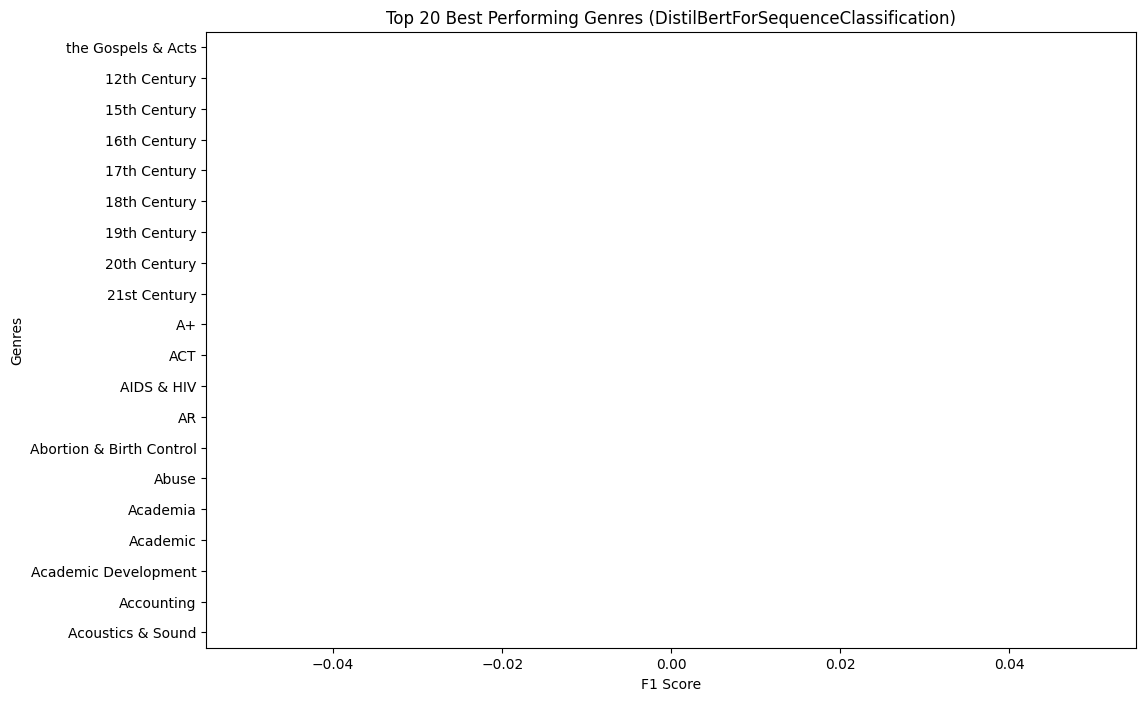

In [20]:
# DistilBERT
try:
    if 'trainer' in locals() and 'tokenizer' in locals():
        # Switching DistilBERT to evaluation mode from training mode
        bert_results = trainer.predict(valid_dataset)
        bert_logits = torch.tensor(bert_results.predictions)
        bert_proba = torch.sigmoid(bert_logits).numpy()
        bert_pred = (bert_proba >= 0.5).astype(int)
        print("DistilBERT predictions:\n", bert_pred)
        print("\n\nDistilBERT predicted probabilities:\n", bert_proba)

        # Produce classification report for DistilBERT predictions
        classification_report_bert = classification_report(y_val, bert_pred, target_names=mlb.classes_)
        print("DistilBERT - Classification Report")
        print("Classification Report:\n", classification_report_bert)
        
        # Calculating F1 scores for each genre to visualise the best performing genres
        f1_scores = f1_score(y_val, bert_pred, average=None)
        genre_f1_scores = pd.DataFrame({'genre': mlb.classes_, 'f1-score': f1_scores})

        # Sort genres by F1 score and show top 20 best performing genres in a horizontal bar chart
        top_20_genres = genre_f1_scores.sort_values(by='f1-score', ascending=False).head(20)
        plt.figure(figsize=(12, 8))
        sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')
        plt.title('Top 20 Best Performing Genres (DistilBertForSequenceClassification)')
        plt.xlabel('F1 Score')
        plt.ylabel('Genres')
        plt.show()
    else:
        print("Error - Loaded DistilBERT model and/or tokenizer not found, unable to prepare sample data for predictions.")
except Exception as e:
    print("Error - Could not prepare sample data for DistilBERT predictions. Result: " + str(e) + ".")

## Save Models

In [21]:
# Make saved_models directory (folder) if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

# Save TF-IDF Vectorizer
try:
    if 'tfidf' in locals() or 'tfidf' in globals():
        joblib.dump(tfidf, 'saved_models/tfidf_vectorizer.joblib')
        print("TF-IDF Vectorizer saved successfully.")
    else:
        print("Error - TF-IDF Vectorizer not found, unable to save.")
except Exception as e:
    print("Error - Could not save TF-IDF Vectorizer. Result: " + str(e) + ".")


# Save Logistic Regression model
try:
    if 'log_reg' in locals() or 'log_reg' in globals():
        joblib.dump(log_reg, 'saved_models/logistic_regression_model.joblib')
        print("Logistic Regression model saved successfully.")
    else:
        print("Error - Logistic Regression model not found, unable to save.")
except Exception as e:
    print("Error - Could not save Logistic Regression model. Result: " + str(e) + ".")

# Save Naive Bayes model
try:
    if 'naive_bayes' in locals() or 'naive_bayes' in globals():
        joblib.dump(naive_bayes, 'saved_models/naive_bayes_model.joblib')
        print("Naive Bayes model saved successfully.")
    else:
        print("Error - Naive Bayes model not found, unable to save.")
except Exception as e:
    print("Error - Could not save Naive Bayes model. Result: " + str(e) + ".")


# Save BERT model and tokenizer
try:
    if ('model' in locals() or 'model' in globals()) and ('tokenizer' in locals() or 'tokenizer' in globals()):
        model.save_pretrained('saved_models/bert_model')
        tokenizer.save_pretrained('saved_models/bert_tokenizer')
        print("DistilBERT model and tokenizer saved successfully.")
    else:
        print("Error - DistilBERT model and/or Tokenizer not found, unable to save.")
except Exception as e:
        print("Error - Could not save DistilBERT and Tokenizer. Result: " + str(e) + ".")

TF-IDF Vectorizer saved successfully.
Logistic Regression model saved successfully.
Naive Bayes model saved successfully.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model and tokenizer saved successfully.


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


DistilBERT predictions:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


DistilBERT predicted probabilities:
 [[0.00015917 0.00015595 0.00069271 ... 0.00137156 0.000427   0.00034653]
 [0.00015715 0.00015543 0.00069304 ... 0.00137573 0.00042409 0.00034825]
 [0.00015757 0.00015564 0.00069273 ... 0.0013779  0.00042678 0.00034778]
 ...
 [0.00015742 0.00015513 0.00069421 ... 0.00136822 0.00042453 0.00034718]
 [0.00015711 0.00015615 0.00069175 ... 0.00138497 0.00042705 0.00034744]
 [0.00015892 0.00015718 0.00069673 ... 0.00138307 0.00043183 0.0003476 ]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

DistilBERT - Classification Report
Classification Report:
                                                            precision    recall  f1-score   support

                                             12th Century       0.00      0.00      0.00         0
                                             15th Century       0.00      0.00      0.00         1
                                             16th Century       0.00      0.00      0.00         1
                                             17th Century       0.00      0.00      0.00         1
                                             18th Century       0.00      0.00      0.00         1
                                             19th Century       0.00      0.00      0.00        35
                                             20th Century       0.00      0.00      0.00        43
                                             21st Century       0.00      0.00      0.00        11
                                                 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_57/3058082423.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')


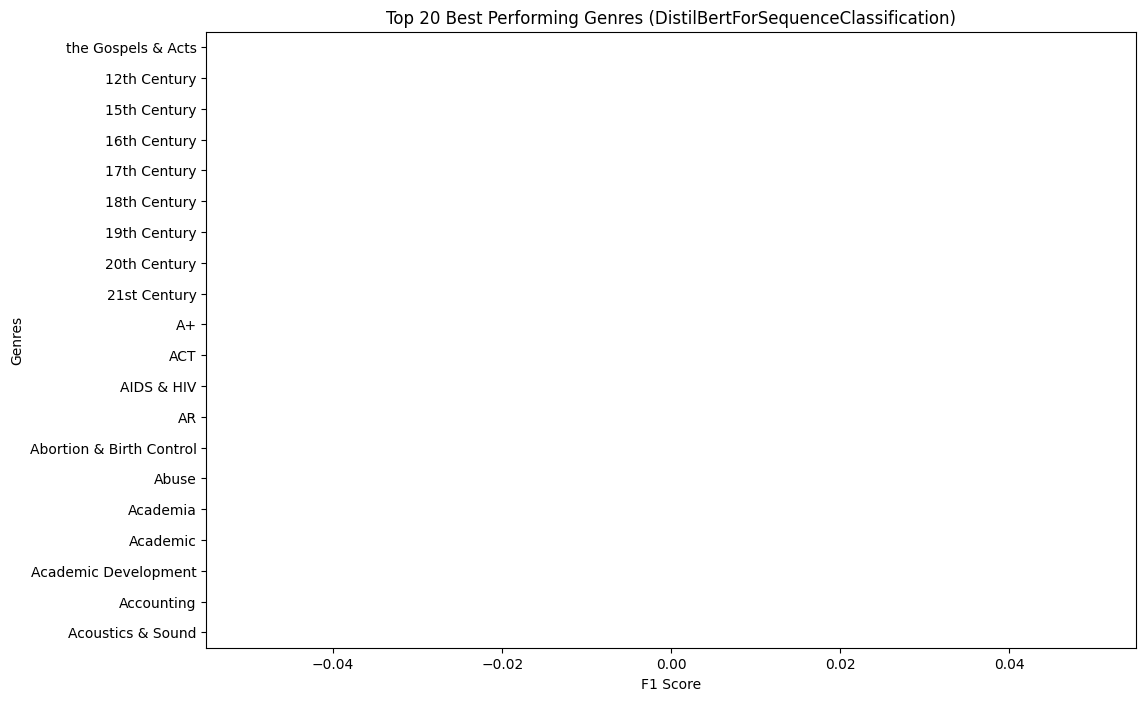

In [22]:
# DistilBERT
try:
    if 'trainer' in locals() and 'tokenizer' in locals():
        # Switching DistilBERT to evaluation mode from training mode
        bert_results = trainer.predict(valid_dataset)
        bert_logits = torch.tensor(bert_results.predictions)
        bert_proba = torch.sigmoid(bert_logits).numpy()
        bert_pred = (bert_proba >= 0.5).astype(int)
        print("DistilBERT predictions:\n", bert_pred)
        print("\n\nDistilBERT predicted probabilities:\n", bert_proba)

        #  classification report for DistilBERT predictions
        classification_report_bert = classification_report(y_val, bert_pred, target_names=mlb.classes_)
        print("DistilBERT - Classification Report")
        print("Classification Report:\n", classification_report_bert)
        
        #  F1 scores for each genre to visualise the best performing genres
        f1_scores = f1_score(y_val, bert_pred, average=None)
        genre_f1_scores = pd.DataFrame({'genre': mlb.classes_, 'f1-score': f1_scores})

        #  genres by F1 score and show top 20 best performing genres in a horizontal bar chart
        top_20_genres = genre_f1_scores.sort_values(by='f1-score', ascending=False).head(20)
        plt.figure(figsize=(12, 8))
        sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')
        plt.title('Top 20 Best Performing Genres (DistilBertForSequenceClassification)')
        plt.xlabel('F1 Score')
        plt.ylabel('Genres')
        plt.show()
    else:
        print("Error - Loaded DistilBERT model and/or tokenizer not found, unable to prepare sample data for predictions.")
except Exception as e:
    print("Error - Could not prepare sample data for DistilBERT predictions. Result: " + str(e) + ".")

In [23]:
print("trainer" in locals())
print("tokenizer" in locals())

True
True


## Load Models before Demo

In [24]:
# Load TF-IDF Vectorizer
try:
    if os.path.exists('saved_models/tfidf_vectorizer.joblib'):
        tfidf_loaded = joblib.load('saved_models/tfidf_vectorizer.joblib')
        print("TF-IDF Vectorizer loaded successfully.")
    else:
        print("Error - TF-IDF Vectorizer file not found, unable to load.")
except Exception as e:
    print("Error - Could not load TF-IDF Vectorizer. Result: " + str(e) + ".")

# Load Logistic Regression model
try:
    if os.path.exists('saved_models/logistic_regression_model.joblib'):
        log_reg_loaded = joblib.load('saved_models/logistic_regression_model.joblib')
        print("Logistic Regression model loaded successfully.")
    else:
        print("Error - Logistic Regression model file not found, unable to load.")
except Exception as e:
    print("Error - Could not load Logistic Regression model. Result: " + str(e) + ".")

# Load Naive Bayes model
try:
    if os.path.exists('saved_models/naive_bayes_model.joblib'):
        naive_bayes_loaded = joblib.load('saved_models/naive_bayes_model.joblib')
        print("Naive Bayes model loaded successfully.")
    else:
        print("Error - Naive Bayes model file not found, unable to load.")
except Exception as e:
    print("Error - Could not load Naive Bayes model. Result: " + str(e) + ".")

# Load BERT model and tokenizer
try:
    if os.path.exists('saved_models/bert_model') and os.path.exists('saved_models/bert_tokenizer'):
        bert_loaded = BertForSequenceClassification.from_pretrained('saved_models/bert_model')
        tokenizer_loaded = BertTokenizer.from_pretrained('saved_models/bert_tokenizer')
        print(" DsitilBERT model and tokenizer loaded successfully.")
    else:
        print("Error - BERT model and/or tokenizer files not found, unable to load.")
except Exception as e:
    print("Error - Could not load DisstilBERT model and tokenizer. Result: " + str(e) + ".")


# Example of using the loaded models to make predictions on new data
sample_books = ["Diary of a Wimpy Kid: Fight or Flight - When the going gets tough, what's a wimpy kid to do? In Fight or Flight, Greg Heffley faces his biggest challenge yet as he becomes a target for the school bully. Luckily for Greg, his best friend, Rowley Jefferson, takes karate, so at least Greg's got someone in his corner. But an unexpected twist makes Greg realize he's facing an uphill battle. Will Greg step into the ring or throw in the towel? One thing's for sure - Fight or Flight is a knockout!",
                "How to Achieve Financial Freedom: A Comprehensive Guide to Building Wealth and Securing Your Future - This comprehensive guide provides practical strategies and insights to help you achieve financial freedom. From budgeting and saving to investing and retirement planning, this book covers all aspects of personal finance. Whether you're just starting your financial journey or looking to take your wealth-building efforts to the next level, this book offers valuable advice and actionable steps to help you secure your financial future.",
                "The wonderful wizard of oz - The Wonderful Wizard of Oz is a children's novel written by L. Frank Baum and illustrated by W. W. Denslow. It was first published in 1900 and has since become one of the most famous and enduring works of American children's literature. The story follows a young girl named Dorothy who is swept away from her Kansas home to the magical land of Oz. Along with her dog Toto, Dorothy embarks on a journey to find the Wizard of Oz, who she believes can help her return home. Along the way, she meets memorable characters such as the Scarecrow, the Tin Woodman, and the Cowardly Lion, who join her on her quest. The novel explores themes of friendship, courage, and self-discovery, and has been adapted into numerous films, stage productions, and other media over the years. The Wonderful Wizard of Oz continues to captivate readers of all ages with its imaginative storytelling and timeless messages.",
                "Boeing 737 MAX: The Inside Story of the World's Deadliest Plane Crash - This book provides an in-depth look at the Boeing 737 MAX, the aircraft involved in two tragic crashes that resulted in the loss of hundreds of lives. It explores the design and development of the plane, the corporate culture at Boeing, and the regulatory failures that contributed to the disasters. Through extensive research and interviews with key players, this book sheds light on the factors that led to the crashes and the ongoing efforts to ensure aviation safety in the future.",
                "The Italian Foodscape: A Culinary Journey Through Italy's Regions - This book takes readers on a culinary journey through Italy's diverse regions, exploring the rich tapestry of flavors and traditions that define Italian cuisine. From the hearty dishes of the north to the vibrant flavors of the south, this book delves into the history, culture, and ingredients that make Italian food so beloved around the world. With recipes, anecdotes, and stunning photography, The Italian Foodscape celebrates the art of Italian cooking and invites readers to experience the magic of Italy's culinary heritage."]

# Transforming new texts using the loaded TF-IDF Vectorizer
try:
    if 'tfidf_loaded' in locals():
        books_tfidf = tfidf_loaded.transform(sample_books)
        print("TF-IDF transformation of the samples successful.")
        print("TF-IDF feature matrix shape for sample books:", books_tfidf.shape)
    else:
        print("Error - Loaded TF-IDF Vectorizer not found, unable to transform new texts.")
except Exception as e:
    print("Error - Could not transform new texts with loaded TF-IDF Vectorizer. Result: " + str(e) + ".")


TF-IDF Vectorizer loaded successfully.
Logistic Regression model loaded successfully.


You are using a model of type distilbert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


Naive Bayes model loaded successfully.


Loading weights:   0%|          | 0/2 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: saved_models/bert_model
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.weight   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.weight   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin1.weight          | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.bias            | UNEXPECTED | 
distilbert.embeddings.position_embeddings.weight                         | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.sa_layer_norm.bias       | UNEXPECTED | 
distilbert.embeddings.LayerNorm.weight

 DsitilBERT model and tokenizer loaded successfully.
TF-IDF transformation of the samples successful.
TF-IDF feature matrix shape for sample books: (5, 5000)


## Predictions by Machine Learning models and Deep Learning model

In [25]:
# Machine Learning - Logistic Regression & Naive Bayes

# Using Logistic Regression model to make predictions
try:
    if 'tfidf_loaded' in locals() and 'log_reg_loaded' in locals():
        log_reg_pred = log_reg_loaded.predict(books_tfidf)
        log_reg_proba = log_reg_loaded.predict_proba(books_tfidf)
        print("Logistic Regression predictions:\n", log_reg_pred)
        print("Logistic Regression predicted probabilities:\n", log_reg_proba, "\n")
    else:
        print("Error - Loaded TF-IDF Vectorizer and/or Logistic Regression model not found, unable to make predictions.")
except Exception as e:
    print("Error - Could not make predictions with Logistic Regression model. Result: " + str(e) + ".")

# Using Naive Bayes model to make predictions
try:
    if 'tfidf_loaded' in locals() and 'naive_bayes_loaded' in locals():
        nb_pred = naive_bayes_loaded.predict(books_tfidf)
        nb_proba = naive_bayes_loaded.predict_proba(books_tfidf)
        print("Naive Bayes predictions:\n", nb_pred)
        print("Naive Bayes predicted probabilities:\n", nb_proba, "\n")
    else:
        print("Error - Loaded TF-IDF Vectorizer and/or Naive Bayes model not found, unable to make predictions.")
except Exception as e:
    print("Error - Could not make predictions with Naive Bayes model. Result: " + str(e) + ".")

# Deep Learning - BERT

# Ensuring that the sample books are properly shown before making predictions with BERT
print("\nSample books for BERT predictions:\n", sample_books, "\n")

# Using BERT model to make predictions
try:
    if 'bert_loaded' in locals() and 'tokenizer_loaded' in locals():
        sample_encodings = tokenizer_loaded(sample_books, padding=True, truncation=True, return_tensors='pt')
        sample_dataset = MultiLabelBookGenreDataset(sample_encodings, y)
        
        # Switching BERT to evaluation mode from training mode
        model.eval()
        with torch.no_grad():
            print("Making predictions with BERT model...")
            outputs = model(**{key: val.to(device) for key, val in sample_encodings.items()})
            bert_logits = outputs.logits
            bert_proba = torch.sigmoid(bert_logits).cpu().numpy()
            bert_pred = (bert_proba >= 0.6).astype(int)
            print(" DistilBERT predictions:\n", bert_pred)
            print("DistilBERT predicted probabilities:\n", bert_proba)
    else:
        print("Error - Loaded DistilBERT model and/or tokenizer not found, unable to prepare sample data for predictions.")
except Exception as e:
    print("Error - Could not prepare sample data for DistilBERT predictions. Result: " + str(e) + ".")


Logistic Regression predictions:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Logistic Regression predicted probabilities:
 [[0.00019097 0.00018998 0.00028464 ... 0.00217728 0.0003817  0.00019102]
 [0.00017458 0.00017745 0.00024679 ... 0.00145544 0.00036609 0.00017611]
 [0.00017502 0.00017619 0.00025428 ... 0.00218966 0.00036574 0.00017394]
 [0.00017911 0.00017743 0.00027073 ... 0.00194749 0.00040629 0.00018076]
 [0.00018272 0.0001813  0.0002818  ... 0.00161668 0.00039823 0.00018219]] 

Naive Bayes predictions:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Naive Bayes predicted probabilities:
 [[1.21092839e-05 1.20851233e-05 7.42640516e-05 ... 1.58997394e-03
  1.35494856e-04 1.21237088e-05]
 [4.86426422e-07 4.95378276e-07 2.92980448e-06 ... 7.75736444e-05
  6.11874391e-06 4.91742559e-07]
 [8.39268127e-07 8.46453867e-07 5.19212216e-06 ... 1.92889401e-04
  1.04287085e-05 8.35307557e-07]

## hamming loss for DistilBert


In [46]:

from sklearn.metrics import hamming_loss

hl_bert = hamming_loss(y_val, bert_pred)
print("DistilBERT Hamming Loss: ",hl_bert )

DistilBERT Hamming Loss:  0.0013938215302686668


### prediction


In [26]:
#  predictions for Logistic Regression
log_reg_preds = log_reg_loaded.predict(X_val_tfidf)

# predictions for Naive Bayes
nb_preds = naive_bayes_loaded.predict(X_val_tfidf)

#  predictions for DistilBERT
# We need to run the validation dataset through the trainer or model
print("Generating DistilBERT predictions for validation set...")
bert_results = trainer.predict(valid_dataset)
# Ccnvert logits to binary (0 or 1) using a threshold
bert_proba = torch.sigmoid(torch.tensor(bert_results.predictions))
bert_pred = (bert_proba >= 0.5).numpy() 

print("All prediction variables defined!")

Generating DistilBERT predictions for validation set...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


All prediction variables defined!


## Data Visualisation


/tmp/ipykernel_57/4254311739.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=f1_scores, palette='magma')


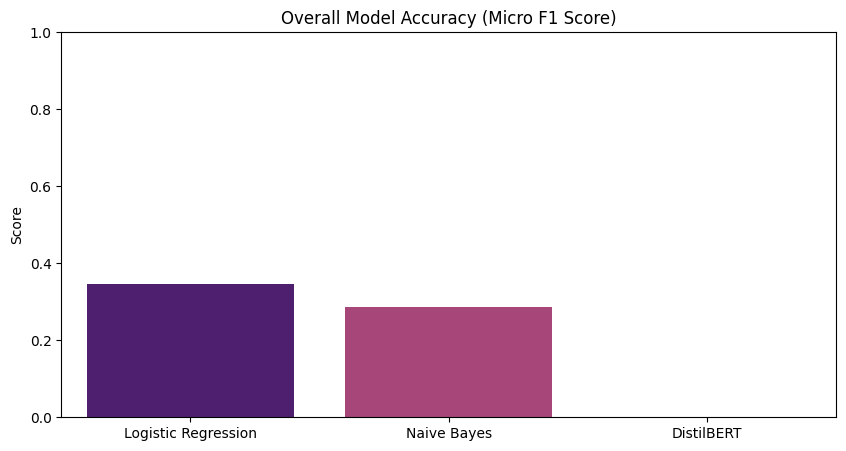

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

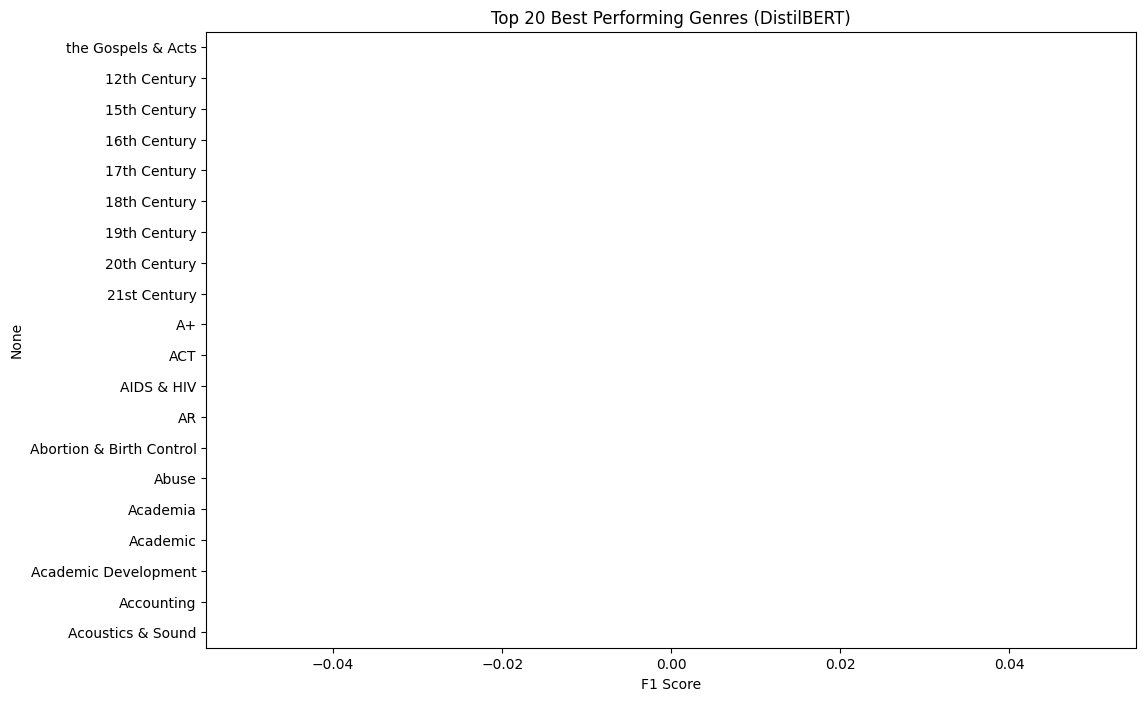

In [27]:
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# data for the model comparison graph
models = ['Logistic Regression', 'Naive Bayes', 'DistilBERT']
f1_scores = [
    f1_score(y_val, log_reg_preds, average='micro'),
    f1_score(y_val, nb_preds, average='micro'),
    f1_score(y_val, bert_pred, average='micro')
]

plt.figure(figsize=(10, 5))
sns.barplot(x=models, y=f1_scores, palette='magma')
plt.title('Overall Model Accuracy (Micro F1 Score)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()

# top 20 genres for DistilBERT
report = classification_report(y_val, bert_pred, target_names=mlb.classes_, output_dict=True)
genre_stats = pd.DataFrame(report).transpose().drop(
    ['micro avg', 'macro avg', 'weighted avg', 'samples avg'], errors='ignore')

top_20_genres = genre_stats.sort_values(by='f1-score', ascending=False).head(20)
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_genres['f1-score'], y=top_20_genres.index, palette='viridis')
plt.title('Top 20 Best Performing Genres (DistilBERT)')
plt.xlabel('F1 Score')
plt.show()

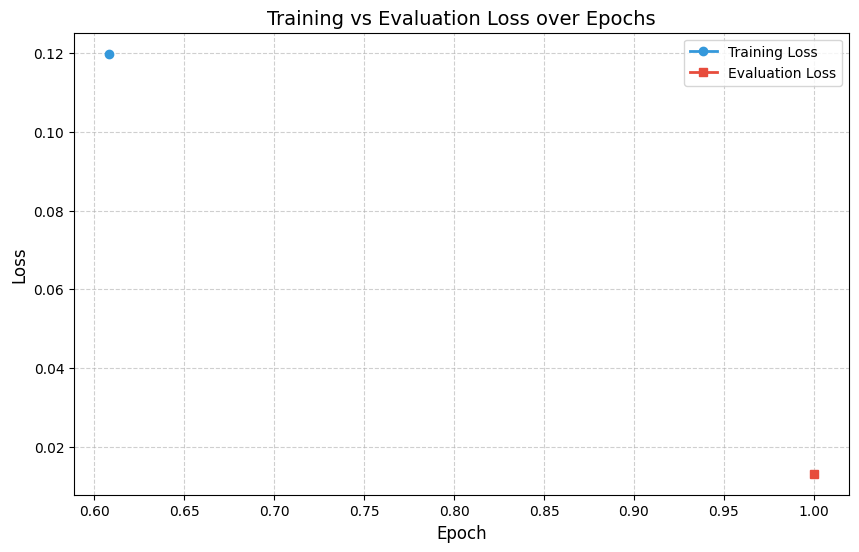

In [28]:

#extract log history into a DataFrame
history = pd.DataFrame(trainer.state.log_history)

# filter for training and evaluation logs
# training loss
train_loss = history[history['loss'].notna()][['epoch', 'loss']]

eval_loss = history[history['eval_loss'].notna()][['epoch', 'eval_loss']]

#create the plot
plt.figure(figsize=(10, 6))
plt.plot(train_loss['epoch'], train_loss['loss'], label='Training Loss', color='#3498db', linewidth=2, marker='o')
plt.plot(eval_loss['epoch'], eval_loss['eval_loss'], label='Evaluation Loss', color='#e74c3c', linewidth=2, marker='s')

#formatting
plt.title('Training vs Evaluation Loss over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Demo
### Interactive demo using widgets

In [29]:
import ipywidgets as widgets
from IPython.display import display, clear_output
#import torch
#import numpy as np

title = widgets.HTML("<h2 style='color:#4A90D9'> Book Genre Predictor</h2>")
subtitle = widgets.HTML("<p>Enter a book summary below and the model will predict its genres.</p>")

text_input = widgets.Textarea(
    placeholder='Enter a book summary here...',
    layout=widgets.Layout(width='600px', height='120px')
)

predict_button = widgets.Button(
    description='Predict Genres',
    button_style='primary',
    icon='book'
)

output = widgets.Output()

def predict_genres(b):
    with output:
        clear_output()
        summary = text_input.value.strip()
        
        if not summary:
            print(" Please enter a book summary first!")
            return
        
        print(" Predicting genres...")
        
        #  Logistic Regression prediction 
        tfidf_input = tfidf.transform([summary])
        lr_pred = log_reg.predict(tfidf_input)
        lr_genres = mlb.inverse_transform(lr_pred)
        
        #  Naive Bayes prediction 
        nb_pred = naive_bayes.predict(tfidf_input)
        nb_genres = mlb.inverse_transform(nb_pred)
        
        #  DistilBERT prediction 
        encoding = tokenizer(
            [summary],
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )
        encoding = {k: v.to(device) for k, v in encoding.items()}
        
        model.eval()
        with torch.no_grad():
            outputs = model(**encoding)
            proba = torch.sigmoid(outputs.logits).cpu().numpy()
            bert_pred = (proba >= 0.5).astype(int)
            bert_genres = mlb.inverse_transform(bert_pred)
        
        # results
        print("\n" + "="*50)
        print(" Input Summary:")
        print(summary[:200] + "..." if len(summary) > 200 else summary)
        print("="*50)
        print(f"\n Logistic Regression:  {', '.join(lr_genres[0]) if lr_genres[0] else 'No genres predicted'}")
        print(f" Naive Bayes:          {', '.join(nb_genres[0]) if nb_genres[0] else 'No genres predicted'}")
        print(f" DistilBERT:           {', '.join(bert_genres[0]) if bert_genres[0] else 'No genres predicted'}")
        print("="*50)

predict_button.on_click(predict_genres)

display(title, subtitle, text_input, predict_button, output)

HTML(value="<h2 style='color:#4A90D9'> Book Genre Predictor</h2>")

HTML(value='<p>Enter a book summary below and the model will predict its genres.</p>')

Textarea(value='', layout=Layout(height='120px', width='600px'), placeholder='Enter a book summary here...')

Button(button_style='primary', description='Predict Genres', icon='book', style=ButtonStyle())

Output()

In [30]:
# test Cases for Demo
test_summaries = [
    {
        "title": "Harry Potter (Fantasy)",
        "summary": "A young wizard discovers he has magical powers and is accepted into a school of witchcraft and wizardry where he learns about a dark wizard who murdered his parents."
    },
    {
        "title": "Murder Mystery (Crime/Thriller)",
        "summary": "A detective investigates a series of mysterious murders in a small coastal town, uncovering dark secrets and a web of lies that leads to a shocking conclusion."
    },
    {
        "title": "Romance Novel",
        "summary": "Two strangers meet by chance in a small Italian village and fall deeply in love, but must overcome their difficult pasts and families who disapprove of their relationship."
    },
    {
        "title": "Science Fiction",
        "summary": "In the year 2150, a crew of astronauts embarks on a mission to colonise Mars but encounter an alien civilisation that challenges everything humanity knows about the universe."
    },
    {
        "title": "History (Non-Fiction)",
        "summary": "A detailed account of the Second World War covering the major battles, political decisions, and the lives of soldiers and civilians caught in the conflict across Europe and the Pacific."
    }
]

print("="*60)
print(" DEMO TEST RESULTS")
print("="*60)

for test in test_summaries:
    print(f"\n {test['title']}")
    print(f"Summary: {test['summary'][:80]}...")
    
    #  LR and NB
    tfidf_input = tfidf.transform([test['summary']])
    lr_pred = log_reg.predict(tfidf_input)
    nb_pred = naive_bayes.predict(tfidf_input)
    lr_genres = mlb.inverse_transform(lr_pred)
    nb_genres = mlb.inverse_transform(nb_pred)
    
    # DistilBERT
    encoding = tokenizer(
        [test['summary']],
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )
    encoding = {k: v.to(device) for k, v in encoding.items()}
    
    model.eval()
    with torch.no_grad():
        outputs = model(**encoding)
        proba = torch.sigmoid(outputs.logits).cpu().numpy()
        bert_pred = (proba >= 0.5).astype(int)
        bert_genres = mlb.inverse_transform(bert_pred)
    
    print(f"   Logistic Regression: {', '.join(lr_genres[0]) if lr_genres[0] else 'None'}")
    print(f"   Naive Bayes:         {', '.join(nb_genres[0]) if nb_genres[0] else 'None'}")
    print(f"   DistilBERT:          {', '.join(bert_genres[0]) if bert_genres[0] else 'None'}")
    print("-"*60)

print("\n All test cases complete!")

 DEMO TEST RESULTS

 Harry Potter (Fantasy)
Summary: A young wizard discovers he has magical powers and is accepted into a school of ...
   Logistic Regression: Fantasy, General
   Naive Bayes:         Fantasy, Fiction
   DistilBERT:          None
------------------------------------------------------------

 Murder Mystery (Crime/Thriller)
Summary: A detective investigates a series of mysterious murders in a small coastal town,...
   Logistic Regression: Fiction, General, Mystery
   Naive Bayes:         Fiction, General
   DistilBERT:          None
------------------------------------------------------------

 Romance Novel
Summary: Two strangers meet by chance in a small Italian village and fall deeply in love,...
   Logistic Regression: Fiction
   Naive Bayes:         Fiction
   DistilBERT:          None
------------------------------------------------------------

 Science Fiction
Summary: In the year 2150, a crew of astronauts embarks on a mission to colonise Mars but...
   Logist